# 06 Visualizing PCs

In [91]:
import numpy as np
import scipy as sp
import pandas as pd
import sys
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import pickle as pkl
from collections import defaultdict

from statsmodels.api import OLS

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

sys.path.append('../..')
from nonlinear_significance.scripts.TreeTester import TreeTester
from nonlinear_significance.scripts.util import TreeTransformer

from simulations_util import *

## 1. Linear model

In [129]:
n = 200
p = 10
s = 2
sigma = 5
beta = 1
X = np.random.randn(2*n, p)
y = linear_model(X, sigma, s, beta)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5)

rf_model = RandomForestRegressor(max_features=0.33)
rf_model.fit(X_train, y_train)

In [193]:
output_file = "results/lin_pca_experiment.pkl"
# experiment = {"rf_model": rf_model,
#               "X_train": X_train,
#               "y_train": y_train,
#               "X_val": X_val,
#               "y_val": y_val}
# pkl.dump(experiment, open(output_file, "wb"))
rf_model, X_train, y_train, X_val, y_val = pkl.load(open(output_file, "rb")).values()
tree_transformer = TreeTransformer(rf_model, max_components="median")
tree_transformer.fit(X_val, y_val)

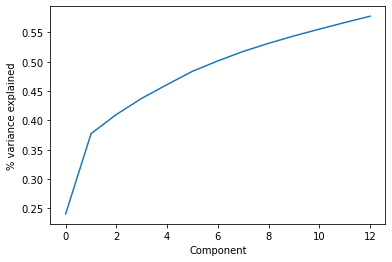

In [198]:
plt.plot(tree_transformer.pca_transformers[0].explained_variance_ratio_.cumsum())
plt.xlabel("Component")
plt.ylabel("% variance explained")
plt.show()

In [195]:
c = 10
lin_fit = OLS(y_val, tree_transformer.transform_one_feature(X_val, 0)).fit()
pca_var_explained = tree_transformer.pca_transformers[0].explained_variance_ratio_[:c]
y_var_explained = np.zeros(c)
correlation = np.zeros(c)
for i in range(c):
    correlation[i] = np.corrcoef(X_val[:, 0], tree_transformer.transform_one_feature(X_val, 0)[:, i])[0,1]
    single_OLS = OLS(tree_transformer.transform_one_feature(X_val, 0)[:,i], y_val).fit()
    y_var_explained[i] = single_OLS.rsquared
pca_results = pd.DataFrame({"pca_var_exp": pca_var_explained,
                            "corr_with_base_feat": correlation,
                            "y_var_explained":y_var_explained,
                            "t-statistic" : lin_fit.tvalues[:c]})

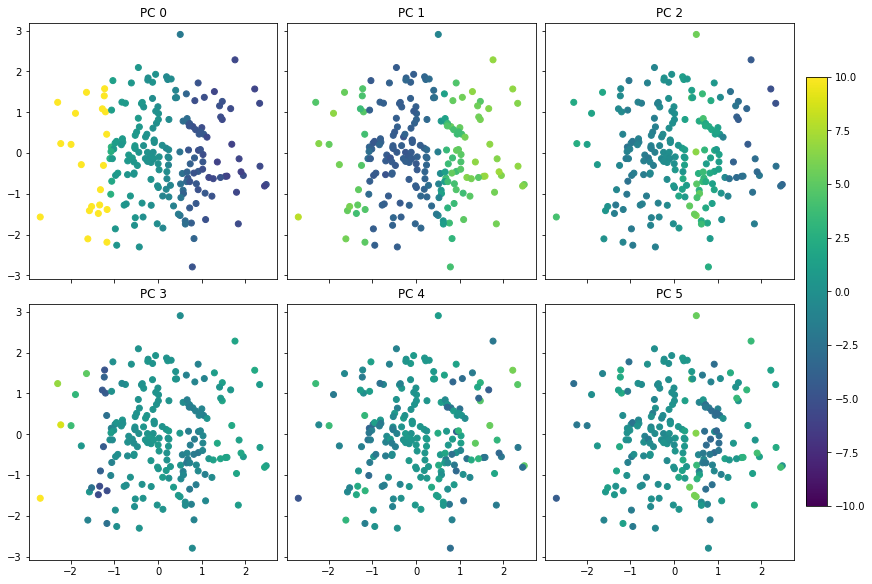

In [196]:
c_plotted = 6
nrow = 2
ncol = c_plotted // nrow
fig, axes = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(4*ncol, 4*nrow), constrained_layout=True)
cmap=cm.get_cmap('viridis')
normalizer=Normalize(-10,10)
im=cm.ScalarMappable(norm=normalizer)
for k in range(c_plotted):
    i = k // ncol
    j = k % ncol
    ax = axes[i, j]
    ax.scatter(X_val[:, 0], X_val[:, 1], c=tree_transformer.transform_one_feature(X_val, 0)[:,k], cmap=cmap, norm=normalizer)
    ax.set_title(f"PC {k}")
    # ax.annotate("Test", xy=(0,0))
cbar = fig.colorbar(im, ax=axes[:, ncol-1], shrink=0.8)
plt.savefig("lin_PCs.png")
plt.show()

In [197]:
pca_results.round(2)

,pca_var_exp,corr_with_base_feat,y_var_explained,t-statistic
0,0.24,-0.84,0.02,-1.88
1,0.14,0.42,0.00,0.38
2,0.03,-0.03,0.00,-0.22
3,0.03,-0.04,0.00,-0.06
4,0.02,0.13,0.00,0.82
5,0.02,0.19,0.01,1.49
6,0.02,-0.04,0.01,1.20
7,0.02,0.12,0.00,0.27
8,0.01,-0.08,0.00,-0.97
9,0.01,-0.06,0.00,0.58


## 2. Sum of squares

In [199]:
n = 200
p = 10
s = 2
sigma = 5
beta = 1
X = np.random.randn(2*n, p)
y = sum_of_squares(X, sigma, s, beta)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5)

rf_model = RandomForestRegressor(max_features=0.33)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_features=0.33)

In [200]:
output_file = "results/ss_pca_experiment.pkl"
experiment = {"rf_model": rf_model,
              "X_train": X_train,
              "y_train": y_train,
              "X_val": X_val,
              "y_val": y_val}
# pkl.dump(experiment, open(output_file, "wb"))
rf_model, X_train, y_train, X_val, y_val = pkl.load(open(output_file, "rb")).values()
tree_transformer = TreeTransformer(rf_model, max_components="median")
tree_transformer.fit(X_val, y_val)

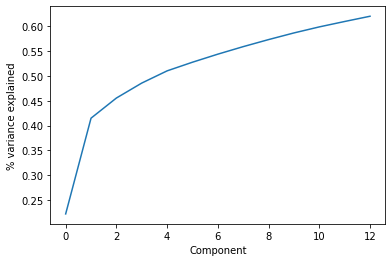

In [201]:
plt.plot(tree_transformer.pca_transformers[0].explained_variance_ratio_.cumsum())
plt.xlabel("Component")
plt.ylabel("% variance explained")
plt.show()

In [189]:
c = 10
lin_fit = OLS(y_val, tree_transformer.transform_one_feature(X_val, 0)).fit()
pca_var_explained = tree_transformer.pca_transformers[0].explained_variance_ratio_[:c]
y_var_explained = np.zeros(c)
correlation = np.zeros(c)
corr_with_sq = np.zeros(c)
for i in range(c):
    correlation[i] = np.corrcoef(X_val[:, 0], tree_transformer.transform_one_feature(X_val, 0)[:, i])[0,1]
    corr_with_sq[i] = np.corrcoef(X_val[:, 0] ** 2, tree_transformer.transform_one_feature(X_val, 0)[:, i])[0,1]
    single_OLS = OLS(tree_transformer.transform_one_feature(X_val, 0)[:,i], y_val).fit()
    y_var_explained[i] = single_OLS.rsquared
pca_results = pd.DataFrame({"pca_var_exp": pca_var_explained,
                            "corr_with_base_feat": correlation,
                            "corr_with_sq": corr_with_sq,
                            "y_var_explained":y_var_explained,
                            "t-statistic" : lin_fit.tvalues[:c]})

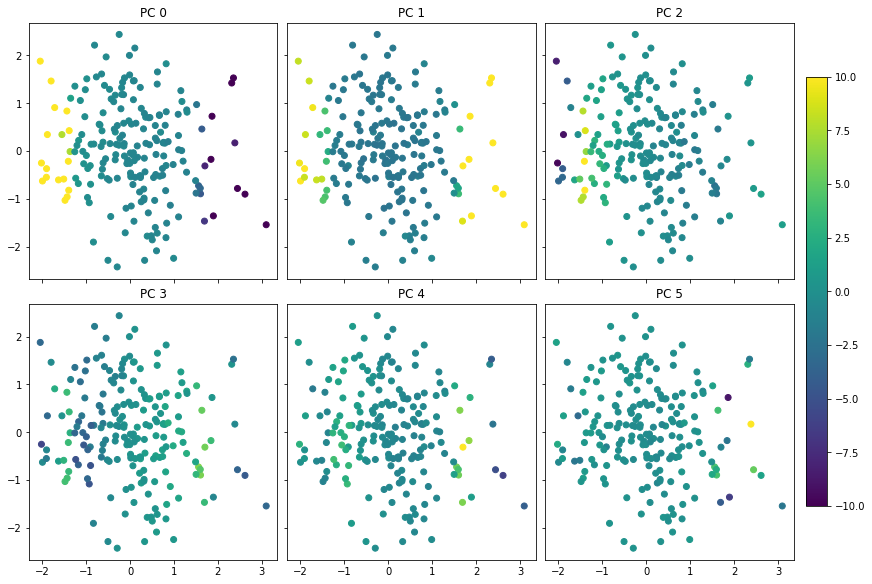

In [190]:
c_plotted = 6
nrow = 2
ncol = c_plotted // nrow
fig, axes = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(4*ncol, 4*nrow), constrained_layout=True)
cmap=cm.get_cmap('viridis')
normalizer=Normalize(-10,10)
im=cm.ScalarMappable(norm=normalizer)
for k in range(c_plotted):
    i = k // ncol
    j = k % ncol
    ax = axes[i, j]
    ax.scatter(X_val[:, 0], X_val[:, 1], c=tree_transformer.transform_one_feature(X_val, 0)[:,k], cmap=cmap, norm=normalizer)
    ax.set_title(f"PC {k}")
    # ax.annotate("Test", xy=(0,0))
cbar = fig.colorbar(im, ax=axes[:, ncol-1], shrink=0.8)
plt.savefig("ss_PCs.png")
plt.show()

In [192]:
pca_results.round(2)

,pca_var_exp,corr_with_base_feat,corr_with_sq,y_var_explained,t-statistic
0,0.22,-0.75,0.05,0.00,-0.00
1,0.19,0.24,0.89,0.04,3.03
2,0.04,-0.27,-0.01,0.00,-0.13
3,0.03,0.41,-0.05,0.04,-2.78
4,0.02,-0.17,0.05,0.00,0.28
5,0.02,0.05,0.18,0.00,-0.64
6,0.02,0.06,0.02,0.00,-0.50
7,0.02,0.06,0.03,0.00,0.22
8,0.01,-0.13,-0.20,0.01,-1.56
9,0.01,0.13,0.00,0.00,0.47


## 3. LSS

In [210]:
n = 200
p = 10
m = 1
r = 2
tau = 0
sigma = 1
beta = 1
X = np.random.randn(2*n, p)
y = lss_model(X, sigma, m, r, tau, beta)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5)

rf_model = RandomForestRegressor(max_features=0.33)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_features=0.33)

In [211]:
output_file = "results/lss_pca_experiment.pkl"
experiment = {"rf_model": rf_model,
              "X_train": X_train,
              "y_train": y_train,
              "X_val": X_val,
              "y_val": y_val}
pkl.dump(experiment, open(output_file, "wb"))
# rf_model, X_train, y_train, X_val, y_val = pkl.load(open(output_file, "rb")).values()
tree_transformer = TreeTransformer(rf_model, max_components="median")
tree_transformer.fit(X_val, y_val)

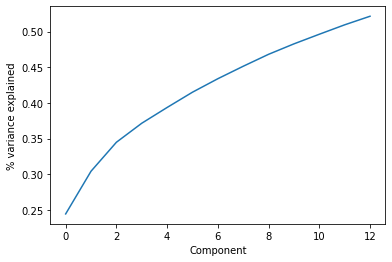

In [212]:
plt.plot(tree_transformer.pca_transformers[0].explained_variance_ratio_.cumsum())
plt.xlabel("Component")
plt.ylabel("% variance explained")
plt.show()

In [213]:
c = 10
lin_fit = OLS(y_val, tree_transformer.transform_one_feature(X_val, 0)).fit()
pca_var_explained = tree_transformer.pca_transformers[0].explained_variance_ratio_[:c]
y_var_explained = np.zeros(c)
correlation = np.zeros(c)
corr_with_indicator = np.zeros(c)
for i in range(c):
    correlation[i] = np.corrcoef(X_val[:, 0], tree_transformer.transform_one_feature(X_val, 0)[:, i])[0,1]
    corr_with_indicator[i] = np.corrcoef((X_val[:, 0] > 0) & (X_val[:, 1] > 0), tree_transformer.transform_one_feature(X_val, 0)[:, i])[0,1]
    single_OLS = OLS(tree_transformer.transform_one_feature(X_val, 0)[:,i], y_val).fit()
    y_var_explained[i] = single_OLS.rsquared
pca_results = pd.DataFrame({"pca_var_exp": pca_var_explained,
                            "corr_with_base_feat": correlation,
                            "corr_with_indicator": corr_with_indicator,
                            "y_var_explained":y_var_explained,
                            "t-statistic" : lin_fit.tvalues[:c]})

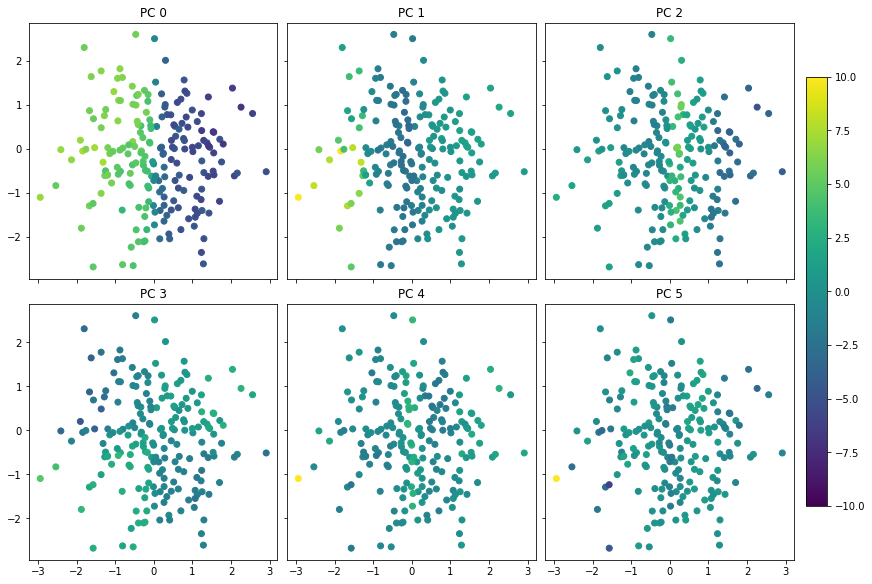

In [214]:
c_plotted = 6
nrow = 2
ncol = c_plotted // nrow
fig, axes = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(4*ncol, 4*nrow), constrained_layout=True)
cmap=cm.get_cmap('viridis')
normalizer=Normalize(-10,10)
im=cm.ScalarMappable(norm=normalizer)
for k in range(c_plotted):
    i = k // ncol
    j = k % ncol
    ax = axes[i, j]
    ax.scatter(X_val[:, 0], X_val[:, 1], c=tree_transformer.transform_one_feature(X_val, 0)[:,k], cmap=cmap, norm=normalizer)
    ax.set_title(f"PC {k}")
    # ax.annotate("Test", xy=(0,0))
cbar = fig.colorbar(im, ax=axes[:, ncol-1], shrink=0.8)
plt.savefig("lss_PCs.png")
plt.show()

In [216]:
pca_results.round(2)

,pca_var_exp,corr_with_base_feat,corr_with_indicator,y_var_explained,t-statistic
0,0.24,-0.88,-0.56,0.03,-2.51
1,0.06,-0.24,0.10,0.00,-0.83
2,0.04,-0.32,0.10,0.00,-0.36
3,0.03,0.00,0.37,0.00,0.07
4,0.02,0.07,-0.09,0.00,-0.10
5,0.02,-0.07,0.03,0.00,-0.00
6,0.02,-0.01,-0.04,0.01,-1.55
7,0.02,-0.06,-0.15,0.01,-1.45
8,0.02,0.09,-0.06,0.00,0.58
9,0.01,-0.04,0.04,0.01,1.27
